# Founder-panel fitness GWAS — all 231 founders (site 4)

Which haploblock allele predicts an **ecotype winning** in the common garden, **controlling for
founder relatedness**? This is the individual-level (founder) view of selection — the dual of the
block-level LD-LMM, and the one that calibrates cleanly.

## The model

A genomic-relatedness mixed model (EMMAX / P3D), exactly a GWAS but with **ecotype fitness as the
trait**.

- **Individuals** = all **231** panel founders. The founding seed mix (8 replicates) contains all
  231 ecotypes, so founders kMate estimates at $\approx 0$ are an **estimation artifact, not real
  absence** — we use the full panel (an earlier 194-founder run, since deleted, dropped them).
- **Trait** $y_f$ = the founder's selection response on the **linear (raw-frequency) scale**: the
  slope of its genome-wide frequency $h_f$ over generations $t=0..3$ at the site, flower-weighted
  across replicate plots, then **quantile-normalized**. Linear (not logit) matches the corrected
  block LD-LMM — the logit floor spuriously inflated rare founders; QN tames the 9764-type winner.
- **Genotype** = the founder's haploblock allele (one-vs-rest, $k-1$ contrasts per dynld-K500
  block). We **test** down to **MAF $\ge$ 1%** (MAC $\ge$ 3) but build the **kinship GRM from
  common markers only (MAF $\ge$ 5%, MAC $\ge$ 12)** — admitting rare markers into the GRM pushes
  the variance component $\delta\to0$ (h$^2\to1$) on some chromosomes and amplifies markers with
  *no marginal signal*; decoupling the GRM from the test set keeps $\delta$ stable.
- **Mixed model** $\;\mathbf y=\mu\mathbf 1+\mathbf x_b\beta_b+\mathbf u+\boldsymbol\varepsilon,\;
  \mathbf u\sim\mathcal N(\mathbf 0,\sigma_g^2\mathbf K_{\text{LOCO}})$, with $\mathbf K$ built
  from common markers **leave-one-chromosome-out** so the tested block is never in its own kinship
  (no proximal contamination / local deflation). EMMAX estimates the variance components per chromosome.

> *Rejected (documented so we don't redo it):* a replicate-**precision** arm (weighting founders by
> inverse replicate variance, even floored at the binomial sampling variance) adds no real
> re-weighting and leaks rare-marker false positives — the honest model is unweighted + QN.

**Result (read with the figures):** the naive scan is badly inflated ($\lambda_{GC}\approx3.6$);
the LOCO kinship correction (common-marker GRM) calibrates it ($\lambda_{GC}\approx1.00$) and
**nothing survives FDR** (best $q\approx0.09$). The top of the ranking is sensible — led by
Chr5:25.77 Mb (marginal $p\approx4\times10^{-13}$, common) — but no block clears multiple testing.
So the ceiling is **collinearity, not measurement noise**: at this site the winners are one clade
and the adaptive allele can't be separated from its clade-wide hitchhikers. The clade-proof route
is *cross-site* convergence (same allele winning via different clades at different gardens).

## Load the precomputed GWAS solution

In [1]:
import os, json
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
os.chdir("/global/scratch/users/tbellg/kmate")
H="results/grenenet_gea/hapfreq"; SITE=4; CHROMS=["Chr1","Chr2","Chr3","Chr4","Chr5"]

In [2]:
g=pd.read_csv(f"{H}/site{SITE}_founder_gwas231.csv")   # chrom,start,end,unit,mac,beta,p_naive,p_kin,q_kin
meta=json.load(open(f"{H}/site{SITE}_founder_gwas231_meta.json"))
m=len(g); bonf=0.05/m
print(f"site {SITE}: ALL {meta['n_founders']} founders | TEST {m:,} markers (MAF>={meta['maf_min']:.0%}) | "
      f"GRM from {meta['M_grm']:,} common markers (MAF>={meta['mac_grm']/meta['n_founders']:.0%})")
print(f"  lambda_GC: naive {meta['lambda_naive']:.2f}  ->  kinship-corrected (LOCO) {meta['lambda_kin']:.2f}")
print(f"  hits: Bonferroni {meta['n_bonf']} | FDR q<0.05 {meta['n_fdr']} | best q={meta['best_q']:.3f}")
print(f"  -> 0 hits: the ceiling is collinearity (winners are one clade), not noise.")

site 4: ALL 231 founders | TEST 41,114 markers (MAF>=1%) | GRM from 34,862 common markers (MAF>=5%)
  lambda_GC: naive 3.56  ->  kinship-corrected (LOCO) 1.00
  hits: Bonferroni 0 | FDR q<0.05 0 | best q=0.086
  -> 0 hits: the ceiling is collinearity (winners are one clade), not noise.


## Manhattan — naive vs LOCO-kinship (common-marker GRM)

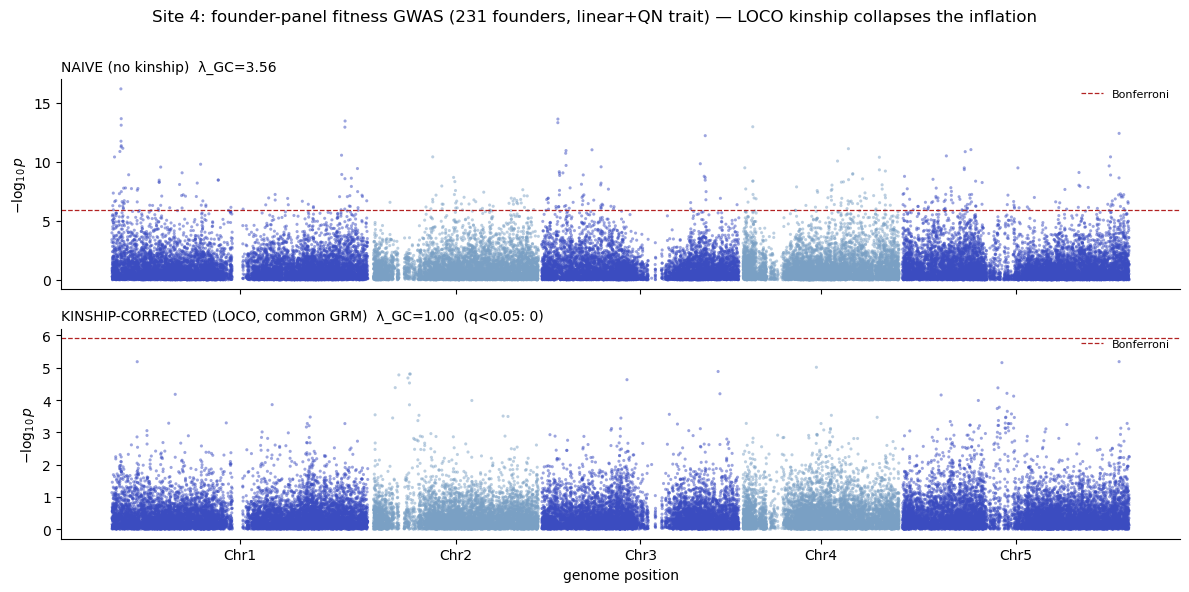

In [3]:
g2=g.copy(); g2["mid"]=(g2.start+g2.end)/2
g2=g2.sort_values(["chrom","start"]).reset_index(drop=True)
off,centers,x=0.0,[],np.zeros(len(g2))
for ch in CHROMS:
    mk=(g2.chrom==ch).to_numpy()
    if not mk.any(): continue
    x[mk]=g2.mid[mk]+off; centers.append(off+g2.mid[mk].max()/2); off+=g2.mid[mk].max()*1.02
g2["x"]=x
fig,ax=plt.subplots(2,1,figsize=(12,6),sharex=True)
for axi,col,tit in [(ax[0],"p_naive",f"NAIVE (no kinship)  λ_GC={meta['lambda_naive']:.2f}"),
                    (ax[1],"p_kin",f"KINSHIP-CORRECTED (LOCO, common GRM)  λ_GC={meta['lambda_kin']:.2f}  (q<0.05: {meta['n_fdr']})")]:
    nlp=-np.log10(np.clip(g2[col],1e-300,1))
    for i,ch in enumerate(CHROMS):
        mk=(g2.chrom==ch).to_numpy()
        axi.scatter(g2.x[mk],nlp[mk],s=5,c=["#3b4cc0","#7aa0c4"][i%2],alpha=.5,edgecolors="none")
    axi.axhline(-np.log10(bonf),color="firebrick",lw=.9,ls="--",label="Bonferroni")
    axi.set_ylabel(r"$-\log_{10}p$"); axi.set_title(tit,loc="left",fontsize=10)
    axi.legend(frameon=False,fontsize=8); axi.spines[["top","right"]].set_visible(False)
ax[1].set_xticks(centers); ax[1].set_xticklabels(CHROMS); ax[1].set_xlabel("genome position")
fig.suptitle(f"Site {SITE}: founder-panel fitness GWAS (231 founders, linear+QN trait) — LOCO kinship collapses the inflation",fontsize=12)
fig.tight_layout(rect=[0,0,1,0.97]); plt.show()

## QQ — kinship-corrected calibrates

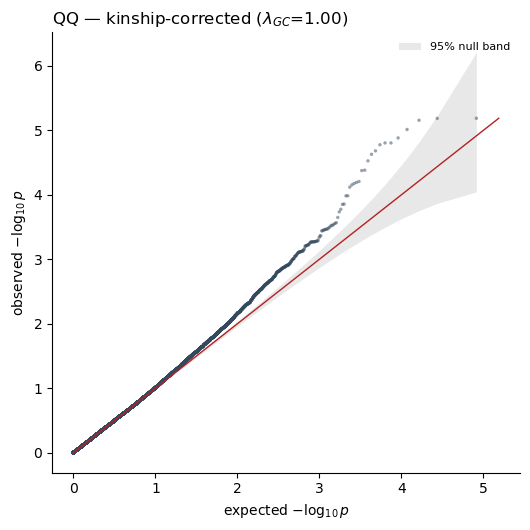

In [4]:
from scipy.stats import beta as _beta
pv=np.sort(g.p_kin.values); exp=-np.log10((np.arange(1,m+1)-0.5)/m); obs=-np.log10(np.clip(pv,1e-300,1))
fig,ax=plt.subplots(figsize=(5.4,5.4))
_i=np.arange(1,m+1); _lo=_beta.ppf(0.025,_i,m-_i+1); _hi=_beta.ppf(0.975,_i,m-_i+1)
ax.fill_between(exp,-np.log10(np.clip(_hi,1e-300,1)),-np.log10(np.clip(_lo,1e-300,1)),color="grey",alpha=.18,lw=0,label="95% null band")
ax.scatter(exp,obs,s=6,c="#34495e",alpha=.5,edgecolors="none")
lim=max(exp.max(),obs.max()); ax.plot([0,lim],[0,lim],color="firebrick",lw=1)
ax.set_xlabel(r"expected $-\log_{10}p$"); ax.set_ylabel(r"observed $-\log_{10}p$")
ax.set_title(f"QQ — kinship-corrected ($\lambda_{{GC}}$={meta['lambda_kin']:.2f})",loc="left")
ax.legend(frameon=False,fontsize=8); ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()

## Top blocks (none reach FDR; Chr5:25.77Mb leads)

In [5]:
# top blocks (none reach FDR; ranked by kinship-corrected p). p_naive vs p_kin: a hit with
# large p_naive but tiny p_kin would be a delta-degeneracy artifact -- here the top hits have real
# marginal signal (small p_naive), led by Chr5:25.77Mb.
g.sort_values("p_kin").head(15)[["chrom","start","end","mac","beta","p_naive","p_kin","q_kin"]]

,chrom,start,end,mac,beta,p_naive,p_kin,q_kin
0,Chr5,25770409,25785898,44.0,0.693123,4.030651e-13,0.000006,0.085873
1,Chr1,3006776,3024933,75.0,-0.520405,2.348945e-03,0.000007,0.085873
2,Chr5,11666830,12019347,45.0,0.660788,6.201768e-02,0.000007,0.085873
3,Chr4,8730611,8732278,75.0,-0.499308,1.329805e-03,0.000010,0.085873
4,Chr3,20974565,20974724,16.0,-0.969509,2.152078e-06,0.000013,0.085873
5,Chr2,4373157,4376083,18.0,0.882554,5.702602e-01,0.000016,0.085873
6,Chr2,4454553,4455825,18.0,0.882554,5.702602e-01,0.000016,0.085873
7,Chr2,3059989,3126888,13.0,1.046753,6.667673e-01,0.000017,0.085873
8,Chr2,4148710,4195097,13.0,1.038364,7.850176e-01,0.000021,0.094920
9,Chr3,10137592,10140976,30.0,0.702916,6.834179e-01,0.000023,0.096560
